
# NFL Football Operations: Next-Season Starter Prediction

## Objective

Build a **football-operations player evaluation model** that estimates:

> **Given everything known about an offensive skill player through season `t`, what is the probability that he starts at least 10 games in season `t+1`?**

This is designed as a roster-planning / player-evaluation problem rather than a fantasy-football problem.

### Primary target

\[
\text{Starter Next Year} =
\begin{cases}
1 & \text{if next-season games started} \ge 10 \\
0 & \text{otherwise}
\end{cases}
\]

### Modeling design

- Players: **QB, RB, WR, TE**
- Observation unit: **one player-season**
- Main source: `yearly_player_stats_offense`
- Training seasons: **2012–2022**
- Validation season: **2023**
- Untouched test season: **2024 → 2025 outcome**
- Deployment-style forecast: **2025 → 2026 starter probabilities**
- Model comparison:
  - prevalence baseline
  - logistic regression
  - random forest
  - XGBoost
  - Bayesian hyperparameter optimization with Optuna
- Evaluation:
  - ROC-AUC
  - PR-AUC / Average Precision
  - Log Loss
  - Brier Score
  - Precision / Recall / F1
- Interpretation:
  - feature importance
  - calibration
  - position-level performance
  - 2026 breakout / starter candidates

The notebook deliberately avoids using future-season variables as predictors.


In [1]:

# Core imports
from pathlib import Path
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)
from sklearn.calibration import calibration_curve

from xgboost import XGBClassifier
import optuna

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
N_TRIALS = int(os.getenv("OPTUNA_TRIALS", "20"))

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)

print(f"Optuna trials: {N_TRIALS}")


Optuna trials: 20



## 1. Load the yearly player dataset

Only the yearly player file is required for this project. This keeps the prediction problem focused and avoids joining extra datasets simply for complexity.

The loader checks a few common filenames so the notebook is easy to move.


In [2]:

DATA_CANDIDATES = [
    Path("yearly_player_stats_offense(2).csv"),
    Path("yearly_player_stats_offense.csv"),
    Path("/mnt/data/yearly_player_stats_offense(2).csv"),
]

DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not find the yearly player CSV. Put it in the same folder as this notebook "
        "or update DATA_CANDIDATES."
    )

raw = pd.read_csv(DATA_PATH)

print("Loaded:", DATA_PATH)
print("Shape:", raw.shape)
print("Seasons:", int(raw["season"].min()), "to", int(raw["season"].max()))
print("\nPosition groups:")
display(raw["position_group"].value_counts(dropna=False).head(15).to_frame("rows"))


Loaded: yearly_player_stats_offense.csv
Shape: (10856, 591)
Seasons: 2012 to 2025

Position groups:


,rows
position_group,
WR,3837
RB,2839
TE,2068
QB,1291
OL,343
SPEC,216
DB,189
LB,44
DL,29



## 2. Restrict to relevant offensive skill players

The dataset includes occasional rows from special-teamers and defensive players. For this question, we focus on:

- QB
- RB
- WR
- TE

We also use regular-season observations only.


In [3]:

POSITIONS = ["QB", "RB", "WR", "TE"]

players = raw.loc[
    raw["season_type"].astype(str).str.upper().eq("REG")
    & raw["position_group"].isin(POSITIONS)
].copy()

players = players.sort_values(["player_id", "season", "team"]).reset_index(drop=True)

print("Rows after filtering:", len(players))
display(players["position_group"].value_counts().to_frame("rows"))


Rows after filtering: 8142


,rows
position_group,
WR,3072
RB,2310
TE,1683
QB,1077



## 3. Collapse traded players to one player-season

A number of traded players appear in multiple rows for the same season—one row for each team—while their season-level statistics are repeated.

Treating those rows as independent samples would:

1. overweight traded players,
2. leak duplicate information across observations,
3. distort evaluation.

We therefore retain one record per `player_id × season` and label the team `MULTI` when the player appears for multiple clubs.


In [4]:

team_counts = (
    players.groupby(["player_id", "season"])["team"]
    .nunique(dropna=True)
)

multi_keys = set(team_counts[team_counts > 1].index)

players = (
    players.drop_duplicates(["player_id", "season"], keep="first")
    .copy()
)

key_index = pd.MultiIndex.from_frame(players[["player_id", "season"]])
multi_mask = np.array([key in multi_keys for key in key_index])

players.loc[multi_mask, "team"] = "MULTI"

print("Unique player-seasons:", len(players))
print("Multi-team player-seasons:", int(multi_mask.sum()))
print("Remaining duplicate player-seasons:",
      int(players.duplicated(["player_id", "season"]).sum()))


Unique player-seasons: 7923
Multi-team player-seasons: 213
Remaining duplicate player-seasons: 0



## 4. Construct the next-season starter target

For every player-season through 2024, we look for the same player in the following season.

- If the player starts **10+ games** next season → `1`
- If he starts fewer than 10 → `0`
- If he does not appear in the following season → `0`
- 2025 is left unlabeled because this dataset does not contain 2026 outcomes

Counting players who leave the league as `0` is important. Removing them would introduce **survivorship bias**.


In [5]:

STARTER_THRESHOLD = 10
MAX_OBSERVED_SEASON = int(players["season"].max())

starts_lookup = {
    (pid, int(season)): float(starts) if pd.notna(starts) else 0.0
    for pid, season, starts
    in players[["player_id", "season", "games_started"]].itertuples(index=False, name=None)
}

players["next_season_games_started"] = np.nan
players["starter_next_year"] = np.nan

labeled_mask = players["season"] < MAX_OBSERVED_SEASON

next_starts = []
for pid, season in players.loc[
    labeled_mask, ["player_id", "season"]
].itertuples(index=False, name=None):
    value = starts_lookup.get((pid, int(season) + 1), 0.0)
    next_starts.append(value)

players.loc[labeled_mask, "next_season_games_started"] = next_starts
players.loc[labeled_mask, "starter_next_year"] = (
    players.loc[labeled_mask, "next_season_games_started"] >= STARTER_THRESHOLD
).astype(int)

print("Target prevalence by season:")
display(
    players.groupby("season")["starter_next_year"]
    .agg(["count", "mean"])
    .rename(columns={"mean": "starter_rate"})
    .tail(10)
)


Target prevalence by season:


,count,starter_rate
season,,
2016,559,0.000000
2017,554,0.223827
2018,567,0.236332
2019,566,0.227915
2020,594,0.237374
2021,610,0.240984
2022,589,0.249576
2023,557,0.249551
2024,563,0.241563



## 5. Initial target analysis

The positive class is intentionally demanding: a player must start at least 10 games the next year.

Because the target is imbalanced, **accuracy alone is not a useful metric**. PR-AUC, probability quality, precision, and recall will matter more.


,count,starter_rate
position_group,,
QB,984,0.202236
TE,1529,0.164160
WR,2751,0.158124
RB,2084,0.101727


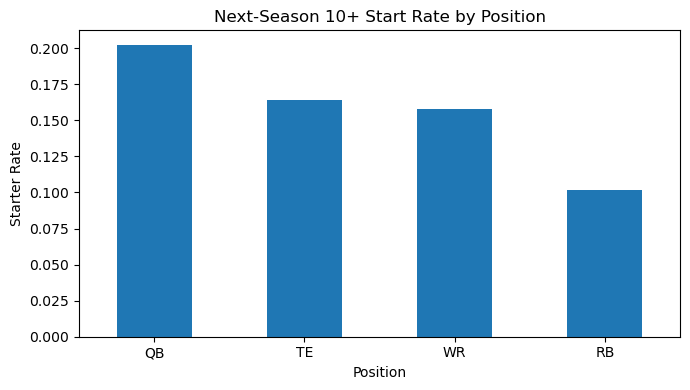

In [6]:

labeled = players[players["starter_next_year"].notna()].copy()

position_rates = (
    labeled.groupby("position_group")["starter_next_year"]
    .agg(["count", "mean"])
    .rename(columns={"mean": "starter_rate"})
    .sort_values("starter_rate", ascending=False)
)

display(position_rates)

plt.figure(figsize=(7, 4))
position_rates["starter_rate"].plot(kind="bar")
plt.title("Next-Season 10+ Start Rate by Position")
plt.ylabel("Starter Rate")
plt.xlabel("Position")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


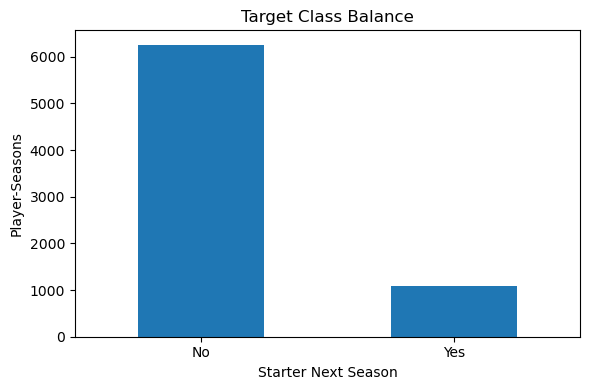

Overall positive rate: 0.1493


In [7]:

class_counts = labeled["starter_next_year"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar")
plt.title("Target Class Balance")
plt.xlabel("Starter Next Season")
plt.ylabel("Player-Seasons")
plt.xticks([0, 1], ["No", "Yes"], rotation=0)
plt.tight_layout()
plt.show()

print("Overall positive rate:", round(labeled["starter_next_year"].mean(), 4))



## 6. Leakage-aware feature engineering

The raw file contains hundreds of already-derived columns such as `trend_`, `avg_`, `rel_to_avg_`, `z_score_`, and `cum_`.

For a portfolio-quality forecasting project, it is safer to avoid relying on transformations whose construction is not fully documented. We therefore:

- keep the underlying season statistics,
- remove IDs and future targets,
- remove fantasy-scoring columns,
- remove pre-engineered aggregate prefixes,
- engineer a small set of transparent football features ourselves.

This makes the information set easier to defend in an interview.


In [8]:

def add_transparent_features(df):
    out = df.copy()

    # Approximate player age on September 1 of the season
    birth = pd.to_datetime(out["birth_date"], errors="coerce")
    season_date = pd.to_datetime(out["season"].astype("Int64").astype(str) + "-09-01", errors="coerce")
    out["age"] = (season_date - birth).dt.days / 365.25

    games = pd.to_numeric(out["games"], errors="coerce").replace(0, np.nan)

    if "games_started" in out:
        out["start_rate"] = pd.to_numeric(out["games_started"], errors="coerce") / games

    rate_features = {
        "touches_per_game": "touches",
        "total_yards_per_game": "total_yards",
        "targets_per_game": "targets",
        "receptions_per_game": "receptions",
        "rush_attempts_per_game": "rush_attempts",
        "rushing_yards_per_game": "rushing_yards",
        "receiving_yards_per_game": "receiving_yards",
        "pass_attempts_per_game": "pass_attempts",
        "passing_yards_per_game": "passing_yards",
        "offense_snaps_per_game": "offense_snaps",
        "total_tds_per_game": "total_tds",
    }

    for new_col, source_col in rate_features.items():
        if source_col in out.columns:
            out[new_col] = pd.to_numeric(out[source_col], errors="coerce") / games

    if "draft_pick" in out:
        dp = pd.to_numeric(out["draft_pick"], errors="coerce")
        out["undrafted"] = dp.isna().astype(int)
        out["draft_pick_log"] = np.log1p(dp)

    return out

model_df = add_transparent_features(players)

print("Shape after transparent feature engineering:", model_df.shape)


Shape after transparent feature engineering: (7923, 608)



### Columns excluded from modeling

We intentionally remove:

- player identifiers and names,
- `birth_date` after converting it to age,
- target / future columns,
- fantasy-scoring variables,
- opaque pre-engineered feature families,
- `college_name` because of very high cardinality.

Current team and position are retained because they are known at the end of season `t`.


In [9]:

EXACT_EXCLUDE = {
    "player_id",
    "pfr_player_id",
    "player_name",
    "birth_date",
    "season_type",
    "starter_next_year",
    "next_season_games_started",
    "college_name",
}

EXCLUDED_PREFIXES = (
    "trend_",
    "avg_",
    "rel_to_avg_",
    "z_score_",
    "cum_",
)

def should_exclude(col):
    lc = col.lower()
    if col in EXACT_EXCLUDE:
        return True
    if col.startswith(EXCLUDED_PREFIXES):
        return True
    if "fantasy" in lc:
        return True
    if lc.startswith("next_"):
        return True
    return False

candidate_features = [
    c for c in model_df.columns
    if not should_exclude(c)
]

print("Candidate features before missingness filtering:", len(candidate_features))


Candidate features before missingness filtering: 132



## 7. Strict chronological split

A random train/test split would let the model train on the future and evaluate on the past. That is inappropriate for a front-office forecasting problem.

We use:

| Set | Feature season | Outcome season |
|---|---:|---:|
| Train | 2012–2022 | 2013–2023 |
| Validation | 2023 | 2024 |
| Test | 2024 | 2025 |
| Forecast | 2025 | 2026 unknown |

The 2024 test set remains untouched during model and hyperparameter selection.


In [10]:

train_df = model_df[model_df["season"].between(2012, 2022)].copy()
val_df   = model_df[model_df["season"].eq(2023)].copy()
test_df  = model_df[model_df["season"].eq(2024)].copy()
forecast_2026_df = model_df[model_df["season"].eq(2025)].copy()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)
print("2026 forecast population:", forecast_2026_df.shape)

assert train_df["starter_next_year"].notna().all()
assert val_df["starter_next_year"].notna().all()
assert test_df["starter_next_year"].notna().all()
assert forecast_2026_df["starter_next_year"].isna().all()


Train: (6228, 608)
Validation: (557, 608)
Test: (563, 608)
2026 forecast population: (575, 608)



## 8. Final feature selection using training data only

Missingness filtering itself is learned only from the training period.

We keep numeric variables that:

- are not more than 90% missing in training,
- have more than one observed value.

Categorical variables are limited to a small, interpretable set.


In [11]:

CATEGORICAL_CANDIDATES = [
    "position_group",
    "position",
    "team",
    "college_conference",
    "draft_team",
    "status",
]

categorical_features = [
    c for c in CATEGORICAL_CANDIDATES
    if c in candidate_features
]

numeric_candidates = [
    c for c in candidate_features
    if c not in categorical_features
    and pd.api.types.is_numeric_dtype(model_df[c])
]

numeric_features = []
for c in numeric_candidates:
    missing_rate = train_df[c].isna().mean()
    nunique = train_df[c].nunique(dropna=True)
    if missing_rate <= 0.90 and nunique > 1:
        numeric_features.append(c)

features = numeric_features + categorical_features

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Total model features:", len(features))
print("\nCategorical:", categorical_features)


Numeric features: 124
Categorical features: 6
Total model features: 130

Categorical: ['position_group', 'position', 'team', 'college_conference', 'draft_team', 'status']


In [12]:

X_train = train_df[features]
y_train = train_df["starter_next_year"].astype(int)

X_val = val_df[features]
y_val = val_df["starter_next_year"].astype(int)

X_test = test_df[features]
y_test = test_df["starter_next_year"].astype(int)

print("Train positive rate:", round(y_train.mean(), 4))
print("Validation positive rate:", round(y_val.mean(), 4))
print("Test positive rate:", round(y_test.mean(), 4))


Train positive rate: 0.132
Validation positive rate: 0.2496
Test positive rate: 0.2416



## 9. Preprocessing pipeline

Numeric variables:
- median imputation
- standardization for linear modeling

Categorical variables:
- most-frequent imputation
- one-hot encoding
- infrequent categories grouped automatically

The same transformation is learned from training data and then applied to future seasons.


In [13]:

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="infrequent_if_exist",
        min_frequency=5,
    )),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features),
])

preprocessor


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['height', 'weight', 'draft_year',
                                  'draft_round', 'draft_pick', 'rookie_season',
                                  'years_exp', 'season', 'games',
                                  'games_started', 'shotgun', 'no_huddle',
                                  'qb_dropback', 'qb_scramble', 'pass_attempts',
                                  'pass_attempts_red_zone', 'pass_att...
                                  'passing_yards', 'passing_air_yards',
                                  'comp_pct', 'ypa', 'ayptarget', 'pass_adot',
                                  'passer_rating', 'pass_touchdown',
                                  'pass_touchdown_red_zone', ...]),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='infrequent_if_exist',
                                                                min_frequency=5))]),
                                 ['position_group', 'position', 'team',
                                  'college_conference', 'draft_team',
                                  'status'])])


## 10. Evaluation helpers

Because the model produces probabilities used for roster decisions, we evaluate both:

1. **Ranking / discrimination** — ROC-AUC and PR-AUC
2. **Probability quality** — Log Loss and Brier Score
3. **Decision threshold behavior** — Precision, Recall, F1, Accuracy


In [14]:

def evaluate_probabilities(y_true, probabilities, threshold=0.50):
    probabilities = np.asarray(probabilities)
    predictions = (probabilities >= threshold).astype(int)

    return {
        "ROC_AUC": roc_auc_score(y_true, probabilities),
        "PR_AUC": average_precision_score(y_true, probabilities),
        "Log_Loss": log_loss(y_true, probabilities, labels=[0, 1]),
        "Brier": brier_score_loss(y_true, probabilities),
        "Accuracy": accuracy_score(y_true, predictions),
        "Precision": precision_score(y_true, predictions, zero_division=0),
        "Recall": recall_score(y_true, predictions, zero_division=0),
        "F1": f1_score(y_true, predictions, zero_division=0),
    }

def show_metrics(name, y_true, probabilities, threshold=0.50):
    metrics = evaluate_probabilities(y_true, probabilities, threshold)
    display(pd.DataFrame(metrics, index=[name]).round(4))
    return metrics



## 11. Baseline: historical starter rate

A model should beat the simplest possible forecast: assign every player the same probability equal to the training-set starter rate.


In [15]:

base_rate = y_train.mean()
baseline_val_prob = np.repeat(base_rate, len(y_val))

baseline_metrics = show_metrics(
    "Prevalence Baseline",
    y_val,
    baseline_val_prob,
)


,ROC_AUC,PR_AUC,Log_Loss,Brier,Accuracy,Precision,Recall,F1
Prevalence Baseline,0.5,0.2496,0.6116,0.2011,0.7504,0.0,0.0,0.0



## 12. Logistic regression benchmark

Logistic regression provides a strong interpretable benchmark and establishes whether the problem contains useful linear signal.


In [16]:

logit = Pipeline([
    ("prep", clone(preprocessor)),
    ("model", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )),
])

logit.fit(X_train, y_train)
logit_val_prob = logit.predict_proba(X_val)[:, 1]

logit_metrics = show_metrics(
    "Logistic Regression",
    y_val,
    logit_val_prob,
)


,ROC_AUC,PR_AUC,Log_Loss,Brier,Accuracy,Precision,Recall,F1
Logistic Regression,0.8794,0.7094,0.9522,0.2914,0.6014,0.3797,0.9424,0.5413



## 13. Random forest benchmark

The random forest adds nonlinear interactions without requiring gradient boosting.


In [17]:

rf = Pipeline([
    ("prep", clone(preprocessor)),
    ("model", RandomForestClassifier(
        n_estimators=600,
        max_depth=10,
        min_samples_leaf=6,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )),
])

rf.fit(X_train, y_train)
rf_val_prob = rf.predict_proba(X_val)[:, 1]

rf_metrics = show_metrics(
    "Random Forest",
    y_val,
    rf_val_prob,
)


,ROC_AUC,PR_AUC,Log_Loss,Brier,Accuracy,Precision,Recall,F1
Random Forest,0.8844,0.7351,0.4447,0.1423,0.7971,0.565,0.8129,0.6667



## 14. Untuned XGBoost

Gradient-boosted trees are well suited to tabular football data because they can capture nonlinear effects and interactions such as:

- age × experience,
- snap share × position,
- draft capital × early-career production,
- current starts × efficiency,
- workload × durability.


In [18]:

xgb_preprocessor = clone(preprocessor)

X_train_xgb = xgb_preprocessor.fit_transform(X_train)
X_val_xgb = xgb_preprocessor.transform(X_val)

positive = y_train.sum()
negative = len(y_train) - positive
scale_pos_weight = negative / max(positive, 1)

xgb_base = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.04,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=3,
    reg_alpha=0.1,
    reg_lambda=2.0,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    scale_pos_weight=scale_pos_weight,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

xgb_base.fit(X_train_xgb, y_train)
xgb_base_val_prob = xgb_base.predict_proba(X_val_xgb)[:, 1]

xgb_base_metrics = show_metrics(
    "XGBoost",
    y_val,
    xgb_base_val_prob,
)


,ROC_AUC,PR_AUC,Log_Loss,Brier,Accuracy,Precision,Recall,F1
XGBoost,0.8916,0.7545,0.4321,0.135,0.8115,0.5876,0.8201,0.6847



## 15. Bayesian hyperparameter optimization with Optuna

We optimize **validation PR-AUC** because only a minority of player-seasons become 10+ game starters the following year.

The test season remains completely untouched.

The default is 20 trials. Increase `OPTUNA_TRIALS` if you want a longer search.


In [19]:

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 250, 900),
        "max_depth": trial.suggest_int("max_depth", 2, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "subsample": trial.suggest_float("subsample", 0.65, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.60, 1.0),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 12.0),
        "gamma": trial.suggest_float("gamma", 0.0, 3.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 3.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 10.0, log=True),
    }

    model = XGBClassifier(
        **params,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        scale_pos_weight=scale_pos_weight,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )

    model.fit(X_train_xgb, y_train)
    prob = model.predict_proba(X_val_xgb)[:, 1]

    return average_precision_score(y_val, prob)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print("Best validation PR-AUC:", round(study.best_value, 5))
print("\nBest parameters:")
display(pd.Series(study.best_params, name="value").to_frame())


  0%|          | 0/20 [00:00<?, ?it/s]

Best validation PR-AUC: 0.76462

Best parameters:


,value
n_estimators,416.000000
max_depth,5.000000
learning_rate,0.044380
subsample,0.910069
colsample_bytree,0.864875
min_child_weight,4.309801
gamma,2.969424
reg_alpha,0.015782
reg_lambda,1.067672


In [20]:

best_xgb = XGBClassifier(
    **study.best_params,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    scale_pos_weight=scale_pos_weight,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

best_xgb.fit(X_train_xgb, y_train)
best_val_prob = best_xgb.predict_proba(X_val_xgb)[:, 1]

tuned_xgb_metrics = show_metrics(
    "Tuned XGBoost",
    y_val,
    best_val_prob,
)


,ROC_AUC,PR_AUC,Log_Loss,Brier,Accuracy,Precision,Recall,F1
Tuned XGBoost,0.8968,0.7646,0.4354,0.1376,0.8043,0.5714,0.8633,0.6877



## 16. Validation model comparison

The purpose of this table is not to pick the model with the highest accuracy. For a player-evaluation model, the strongest candidate should combine:

- high PR-AUC,
- strong ROC-AUC,
- good probability calibration,
- useful precision/recall.


In [21]:

comparison = pd.DataFrame({
    "Prevalence Baseline": baseline_metrics,
    "Logistic Regression": logit_metrics,
    "Random Forest": rf_metrics,
    "XGBoost": xgb_base_metrics,
    "Tuned XGBoost": tuned_xgb_metrics,
}).T

comparison = comparison.sort_values("PR_AUC", ascending=False)
display(comparison.round(4))


,ROC_AUC,PR_AUC,Log_Loss,Brier,Accuracy,Precision,Recall,F1
Tuned XGBoost,0.8968,0.7646,0.4354,0.1376,0.8043,0.5714,0.8633,0.6877
XGBoost,0.8916,0.7545,0.4321,0.1350,0.8115,0.5876,0.8201,0.6847
Random Forest,0.8844,0.7351,0.4447,0.1423,0.7971,0.5650,0.8129,0.6667
Logistic Regression,0.8794,0.7094,0.9522,0.2914,0.6014,0.3797,0.9424,0.5413
Prevalence Baseline,0.5000,0.2496,0.6116,0.2011,0.7504,0.0000,0.0000,0.0000



## 17. Choose a football-operations decision threshold

A fixed 0.50 cutoff is arbitrary.

We choose the threshold on **2023 validation data only** that maximizes F1. The probability itself remains the more useful output for front-office decision-making, but a threshold is useful for classification summaries.


Selected threshold: 0.711
Validation F1: 0.7315


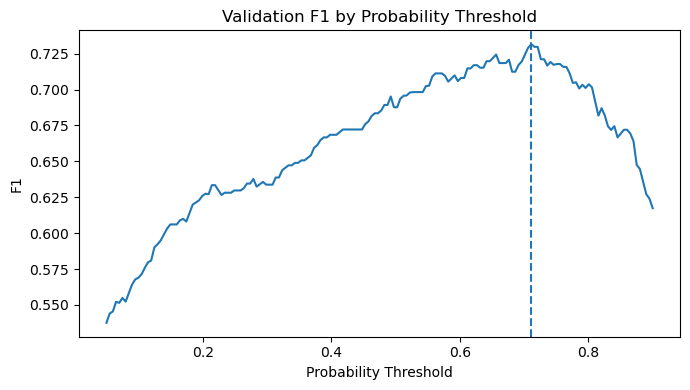

In [22]:

threshold_grid = np.linspace(0.05, 0.90, 172)

threshold_scores = []
for threshold in threshold_grid:
    pred = (best_val_prob >= threshold).astype(int)
    threshold_scores.append(
        (threshold, f1_score(y_val, pred, zero_division=0))
    )

threshold_table = pd.DataFrame(
    threshold_scores,
    columns=["threshold", "f1"]
)

best_threshold = float(
    threshold_table.loc[threshold_table["f1"].idxmax(), "threshold"]
)

print("Selected threshold:", round(best_threshold, 3))
print("Validation F1:", round(threshold_table["f1"].max(), 4))

plt.figure(figsize=(7, 4))
plt.plot(threshold_table["threshold"], threshold_table["f1"])
plt.axvline(best_threshold, linestyle="--")
plt.title("Validation F1 by Probability Threshold")
plt.xlabel("Probability Threshold")
plt.ylabel("F1")
plt.tight_layout()
plt.show()



# 18. Final untouched test: predict 2025 starters from 2024 data

Only now do we evaluate on 2024 player features and 2025 outcomes.

Before testing, the tuned model is refit on **2012–2023**. No 2024 outcome is used for tuning or threshold selection.


In [23]:

train_val_df = model_df[model_df["season"].between(2012, 2023)].copy()

X_train_val = train_val_df[features]
y_train_val = train_val_df["starter_next_year"].astype(int)

final_preprocessor = clone(preprocessor)
X_train_val_xgb = final_preprocessor.fit_transform(X_train_val)
X_test_xgb = final_preprocessor.transform(X_test)

positive_tv = y_train_val.sum()
negative_tv = len(y_train_val) - positive_tv
scale_pos_weight_tv = negative_tv / max(positive_tv, 1)

final_test_model = XGBClassifier(
    **study.best_params,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    scale_pos_weight=scale_pos_weight_tv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

final_test_model.fit(X_train_val_xgb, y_train_val)
test_prob = final_test_model.predict_proba(X_test_xgb)[:, 1]

test_metrics = show_metrics(
    "2024 → 2025 Untouched Test",
    y_test,
    test_prob,
    threshold=best_threshold,
)


,ROC_AUC,PR_AUC,Log_Loss,Brier,Accuracy,Precision,Recall,F1
2024 → 2025 Untouched Test,0.9084,0.7107,0.3796,0.1194,0.8526,0.6879,0.7132,0.7004



## 19. Confusion matrix on the untouched test season


In [24]:

test_pred = (test_prob >= best_threshold).astype(int)
cm = confusion_matrix(y_test, test_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Non-Starter", "Actual Starter"],
    columns=["Predicted Non-Starter", "Predicted Starter"],
)

display(cm_df)


,Predicted Non-Starter,Predicted Starter
Actual Non-Starter,383,44
Actual Starter,39,97



## 20. Probability calibration

For football operations, a player graded at 70% should ideally become a starter roughly 70% of the time among similar predictions.

The reliability curve checks whether the probabilities themselves are useful—not merely the ranking.


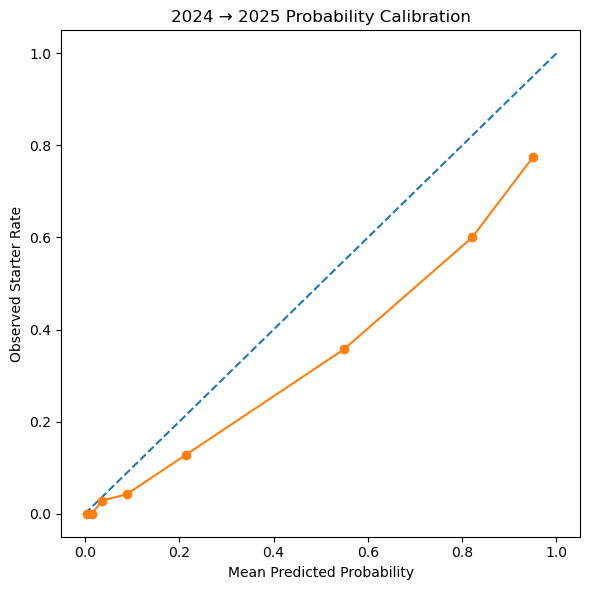

In [25]:

prob_true, prob_pred = calibration_curve(
    y_test,
    test_prob,
    n_bins=8,
    strategy="quantile",
)

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], linestyle="--")
plt.plot(prob_pred, prob_true, marker="o")
plt.title("2024 → 2025 Probability Calibration")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Starter Rate")
plt.tight_layout()
plt.show()



## 21. Performance by position

A single global metric can hide major differences between positions. We therefore evaluate the ranking quality separately for QB, RB, WR, and TE.


In [26]:

position_results = []

test_output = test_df[
    ["player_name", "position_group", "team", "games", "games_started"]
].copy()

test_output["actual_starter_next_year"] = y_test.values
test_output["starter_probability"] = test_prob

for pos, group in test_output.groupby("position_group"):
    y_pos = group["actual_starter_next_year"]
    p_pos = group["starter_probability"]

    row = {
        "position": pos,
        "n": len(group),
        "positive_rate": y_pos.mean(),
        "PR_AUC": np.nan,
        "ROC_AUC": np.nan,
    }

    if y_pos.nunique() == 2:
        row["PR_AUC"] = average_precision_score(y_pos, p_pos)
        row["ROC_AUC"] = roc_auc_score(y_pos, p_pos)

    position_results.append(row)

position_results = pd.DataFrame(position_results).set_index("position")
display(position_results.round(4))


,n,positive_rate,PR_AUC,ROC_AUC
position,,,,
QB,79,0.2911,0.7287,0.9138
RB,142,0.1901,0.7557,0.9214
TE,118,0.2881,0.5505,0.8081
WR,224,0.2321,0.7747,0.9390



## 22. Inspect the strongest and weakest 2024 → 2025 calls

This makes the model concrete: which players did it believe were most likely to become 10+ game starters?


In [27]:

display(
    test_output.sort_values("starter_probability", ascending=False)
    .head(30)
    .reset_index(drop=True)
)


,player_name,position_group,team,games,games_started,actual_starter_next_year,starter_probability
0,Ja'Marr Chase,WR,CIN,17.0,16.0,1,0.988123
1,De'Von Achane,RB,MIA,17.0,16.0,1,0.987118
2,Jordan Addison,WR,MIN,15.0,15.0,1,0.985516
3,A.J. Brown,WR,PHI,13.0,13.0,1,0.984001
4,Drake London,WR,ATL,17.0,17.0,1,0.981547
5,Kyler Murray,QB,ARI,17.0,17.0,0,0.980878
6,Sam Darnold,QB,MIN,17.0,17.0,1,0.980813
7,Mike Evans,WR,TB,14.0,14.0,0,0.979979
8,Breece Hall,RB,NYJ,16.0,16.0,1,0.978751
9,D'Andre Swift,RB,CHI,17.0,17.0,1,0.978284


In [28]:

errors = test_output.copy()
errors["prediction"] = (
    errors["starter_probability"] >= best_threshold
).astype(int)

false_positives = errors[
    (errors["prediction"] == 1)
    & (errors["actual_starter_next_year"] == 0)
].sort_values("starter_probability", ascending=False)

false_negatives = errors[
    (errors["prediction"] == 0)
    & (errors["actual_starter_next_year"] == 1)
].sort_values("starter_probability", ascending=True)

print("Highest-confidence false positives:")
display(false_positives.head(15).reset_index(drop=True))

print("\nLowest-probability false negatives:")
display(false_negatives.head(15).reset_index(drop=True))


Highest-confidence false positives:


,player_name,position_group,team,games,games_started,actual_starter_next_year,starter_probability,prediction
0,Kyler Murray,QB,ARI,17.0,17.0,0,0.980878,1
1,Mike Evans,WR,TB,14.0,14.0,0,0.979979,1
2,Tucker Kraft,TE,GB,17.0,17.0,0,0.978119,1
3,Tyreek Hill,WR,MIA,17.0,17.0,0,0.974668,1
4,Garrett Wilson,WR,NYJ,17.0,17.0,0,0.973478,1
5,Sam LaPorta,TE,DET,16.0,16.0,0,0.973329,1
6,Joe Burrow,QB,CIN,17.0,17.0,0,0.962321,1
7,Brock Purdy,QB,SF,15.0,15.0,0,0.954170,1
8,Foster Moreau,TE,NO,17.0,17.0,0,0.946609,1
9,Jakobi Meyers,WR,LV,15.0,15.0,0,0.937040,1



Lowest-probability false negatives:


,player_name,position_group,team,games,games_started,actual_starter_next_year,starter_probability,prediction
0,Isiah Pacheco,RB,KC,7.0,6.0,1,0.034596,0
1,Kimani Vidal,RB,LAC,10.0,0.0,1,0.053563,0
2,Ian Thomas,TE,CAR,5.0,2.0,1,0.085703,0
3,Jaylen Warren,RB,PIT,15.0,0.0,1,0.099404,0
4,AJ Barner,TE,SEA,17.0,6.0,1,0.112917,0
5,John Bates,TE,WAS,17.0,6.0,1,0.167899,0
6,Payne Durham,TE,TB,16.0,6.0,1,0.175258,0
7,Cedric Tillman,WR,CLE,11.0,6.0,1,0.184813,0
8,Jacoby Brissett,QB,NE,8.0,5.0,1,0.214443,0
9,Alec Ingold,RB,MIA,15.0,10.0,1,0.240740,0



## 23. Feature importance

Feature importance helps translate the model into football language:

- Is current starting experience the dominant signal?
- How much does offensive snap share matter?
- Does draft capital still matter after NFL performance is observed?
- Do receiving/rushing efficiency variables add information?
- How important are age and experience?

XGBoost importance is not causal; it indicates variables the model relied on.


,feature,importance
0,num__games_started,0.236740
1,num__season,0.052259
2,num__start_rate,0.033320
3,num__offense_snaps,0.023110
4,num__offense_pct,0.015162
5,cat__draft_team_LA,0.012354
6,num__offense_snaps_per_game,0.010203
7,num__years_exp,0.008907
8,cat__college_conference_NO FOOTBALL,0.007356
9,cat__college_conference_Pacific Ten Conference,0.007315


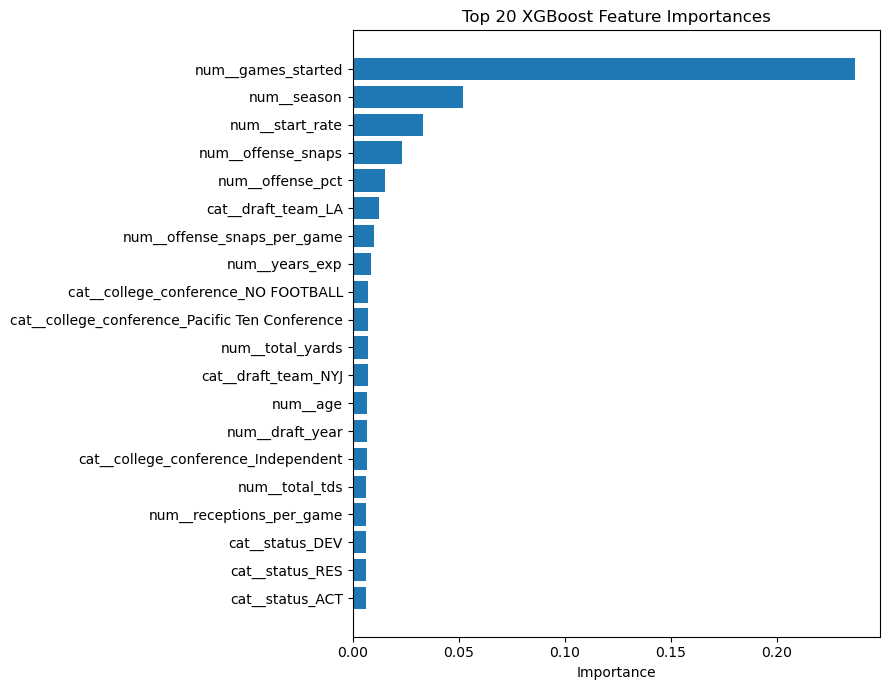

In [29]:

feature_names = final_preprocessor.get_feature_names_out()

importance = pd.DataFrame({
    "feature": feature_names,
    "importance": final_test_model.feature_importances_,
}).sort_values("importance", ascending=False)

display(importance.head(30).reset_index(drop=True))

top_imp = importance.head(20).sort_values("importance")

plt.figure(figsize=(9, 7))
plt.barh(top_imp["feature"], top_imp["importance"])
plt.title("Top 20 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()



# 24. Train the deployment model and forecast 2026

The final deployment model uses every labeled season from **2012–2024**.

It then scores 2025 players to estimate:

> **Probability of starting 10+ games in 2026**

These are forward-looking model outputs. They are not actual 2026 outcomes.

The model does **not** know future:
- injuries,
- free agency,
- trades,
- draft selections,
- coaching changes,
- depth-chart changes,
- contract decisions.

Those would be natural additions to a production football-operations system.


In [30]:

all_labeled = model_df[model_df["season"].between(2012, 2024)].copy()

X_all = all_labeled[features]
y_all = all_labeled["starter_next_year"].astype(int)

deployment_preprocessor = clone(preprocessor)
X_all_xgb = deployment_preprocessor.fit_transform(X_all)
X_2025_xgb = deployment_preprocessor.transform(forecast_2026_df[features])

positive_all = y_all.sum()
negative_all = len(y_all) - positive_all
scale_pos_weight_all = negative_all / max(positive_all, 1)

deployment_model = XGBClassifier(
    **study.best_params,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    scale_pos_weight=scale_pos_weight_all,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

deployment_model.fit(X_all_xgb, y_all)
prob_2026 = deployment_model.predict_proba(X_2025_xgb)[:, 1]

forecast_cols = [
    "player_name",
    "position_group",
    "team",
    "games",
    "games_started",
    "years_exp",
]

if "offense_pct" in forecast_2026_df.columns:
    forecast_cols.append("offense_pct")

forecast_2026 = forecast_2026_df[forecast_cols].copy()
forecast_2026["starter_probability_2026"] = prob_2026
forecast_2026["projected_10_plus_game_starter"] = (
    forecast_2026["starter_probability_2026"] >= best_threshold
).astype(int)

forecast_2026 = forecast_2026.sort_values(
    "starter_probability_2026",
    ascending=False,
)

display(forecast_2026.head(50).reset_index(drop=True))


,player_name,position_group,team,games,games_started,years_exp,offense_pct,starter_probability_2026,projected_10_plus_game_starter
0,Jahmyr Gibbs,RB,DET,17.0,17.0,4,0.670000,0.991735,1
1,Bijan Robinson,RB,ATL,17.0,17.0,4,0.781765,0.990399,1
2,De'Von Achane,RB,MIA,16.0,16.0,4,0.753750,0.985799,1
3,Ashton Jeanty,RB,LV,17.0,17.0,2,0.778824,0.984821,1
4,Breece Hall,RB,NYJ,16.0,16.0,5,0.643750,0.982044,1
5,Drake London,WR,ATL,12.0,12.0,5,0.906667,0.981645,1
6,Caleb Williams,QB,CHI,17.0,17.0,3,0.991579,0.980052,1
7,Trey McBride,TE,ARI,17.0,17.0,5,0.913529,0.979332,1
8,George Pickens,WR,DAL,17.0,15.0,5,0.811176,0.976950,1
9,Drake Maye,QB,NE,17.0,17.0,3,0.965714,0.976372,1



## 25. Breakout candidates

For player-acquisition and roster-planning purposes, the most interesting names may not be established starters.

This table filters to players who started **fewer than 10 games in 2025** and ranks them by their estimated probability of becoming a 10+ game starter in 2026.


In [31]:

breakout_candidates = forecast_2026[
    pd.to_numeric(forecast_2026["games_started"], errors="coerce").fillna(0) < 10
].copy()

display(
    breakout_candidates.head(40)
    .reset_index(drop=True)
)


,player_name,position_group,team,games,games_started,years_exp,offense_pct,starter_probability_2026,projected_10_plus_game_starter
0,Sam LaPorta,TE,DET,9.0,9.0,4,0.906667,0.919953,1
1,Bucky Irving,RB,TB,10.0,9.0,3,0.616000,0.918801,1
2,Garrett Wilson,WR,NYJ,7.0,7.0,5,0.870000,0.859702,1
3,Rashee Rice,WR,KC,8.0,8.0,4,0.748750,0.858691,1
4,Cam Skattebo,RB,NYG,8.0,5.0,2,0.522500,0.840660,1
5,Brock Bowers,TE,LV,12.0,8.0,3,0.859167,0.822153,1
6,Keon Coleman,WR,BUF,13.0,6.0,3,0.624000,0.798063,1
7,Dalton Schultz,TE,HOU,17.0,6.0,9,0.685789,0.780322,1
8,Tucker Kraft,TE,GB,8.0,8.0,4,0.860000,0.755488,1
9,Oronde Gadsden II,TE,LAC,15.0,7.0,2,0.615000,0.725237,1



## 26. Breakout candidates by position


In [32]:

top_by_position = (
    breakout_candidates
    .sort_values(
        ["position_group", "starter_probability_2026"],
        ascending=[True, False]
    )
    .groupby("position_group", group_keys=False)
    .head(10)
)

display(
    top_by_position[
        [
            "player_name",
            "position_group",
            "team",
            "games_started",
            "starter_probability_2026",
        ]
    ].reset_index(drop=True)
)


,player_name,position_group,team,games_started,starter_probability_2026
0,Brock Purdy,QB,SF,9.0,0.719645
1,Joe Burrow,QB,CIN,8.0,0.695434
2,Justin Fields,QB,NYJ,9.0,0.641720
3,Kyler Murray,QB,ARI,5.0,0.504624
4,Carson Wentz,QB,MIN,5.0,0.455708
5,Marcus Mariota,QB,WAS,8.0,0.439395
6,Kirk Cousins,QB,ATL,8.0,0.403034
7,Michael Penix Jr.,QB,ATL,9.0,0.399564
8,Mac Jones,QB,SF,8.0,0.381360
9,Anthony Richardson,QB,IND,0.0,0.333592



## 27. Export the 2026 player board

The final CSV can be used as a simple football-operations probability board.


In [33]:

OUTPUT_PATH = Path("nfl_2026_starter_probabilities.csv")
forecast_2026.to_csv(OUTPUT_PATH, index=False)

print("Saved:", OUTPUT_PATH.resolve())


Saved: /Users/svlahos/Downloads/nfl_2026_starter_probabilities.csv



# 28. Football-operations interpretation

## What this model can answer

The model is useful as an initial screening tool for questions such as:

- Which current backups have starter-level profiles?
- Which young players appear likely to earn larger roles?
- Which former high draft picks still have strong future-role probabilities?
- Which current starters have warning signs for losing a starting role?
- Which positions are easiest or hardest to forecast?
- Which measurable player characteristics are most associated with future starting opportunity?

## What the model cannot know

A 10+ game starting outcome depends on more than player performance. Important omitted information includes:

- injuries and medical history,
- contract status and cap implications,
- future free agency,
- trades,
- incoming rookies,
- depth-chart competition,
- coaching and scheme changes,
- practice performance,
- film grades,
- blocking assignments and route responsibility,
- team-specific scouting evaluations.

Therefore the output should be interpreted as a **quantitative player-evaluation signal**, not a final personnel decision.

## Why this is a useful portfolio project

The workflow demonstrates:

1. a football-operations question rather than a generic ML target,
2. duplicate/trade handling,
3. survivorship-bias prevention,
4. leakage-aware feature construction,
5. chronological model validation,
6. imbalanced classification,
7. linear and nonlinear benchmarks,
8. Bayesian hyperparameter optimization,
9. probability calibration,
10. position-level diagnostics,
11. model interpretation,
12. forward-looking 2026 player rankings.

That is much closer to how a football analytics group would expect a predictive project to be framed.
